# Phase 2b: OCR on PDFs and benchmarking

In this phase we will explore several open source OCR model on our articles and compare the results to the md files Hugging Face produced with chandra2. 

In [3]:
import os
from dotenv import load_dotenv

_ = load_dotenv(override=True)

In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any
import duckdb
from pdf2image import convert_from_path

## Creating the df with pdf paths

In [2]:
# Create a df with the pdf file paths and the corresponding image file paths
conn = duckdb.connect("./data/arxiv_metadata.duckdb")
df = conn.execute(
    """
    SELECT *
    FROM papers
    WHERE pdf_path IS NOT NULL AND latex_extracted = True
    """
).fetchdf()

conn.close()

In [3]:
df.head()

,arxiv_id,title,abstract,submitted_date,updated_date,primary_category,doi,comments,license,version_count,github_url,has_code,pdf_path,latex_source_path,latex_extracted
0,2401.01623,Can AI Be as Creative as Humans?,Creativity serves as a cornerstone for socie...,2024-01-03,2024-01-26,cs.AI,None,"The paper examines AI's creativity, introducin...",http://arxiv.org/licenses/nonexclusive-distrib...,4,None,False,data/raw/pdfs/2401.01623.pdf,data/raw/sources/2401.01623.tar.gz,True
1,2401.02118,Radio Map-Based Spectrum Sharing for Joint Com...,The sixth-generation (6G) network is expecte...,2024-01-04,2024-06-28,cs.IT,None,None,http://arxiv.org/licenses/nonexclusive-distrib...,2,None,False,data/raw/pdfs/2401.02118.pdf,data/raw/sources/2401.02118.tar.gz,True
2,2401.02687,PAHD: Perception-Action based Human Decision M...,Synthetic Aperture Radar (SAR) images are co...,2024-01-05,2024-01-08,cs.CV,None,None,http://creativecommons.org/licenses/by/4.0/,1,None,False,data/raw/pdfs/2401.02687.pdf,data/raw/sources/2401.02687.tar.gz,True
3,2401.05171,Multivariate Extreme Value Theory Based Rate S...,Diversity schemes play a vital role in impro...,2024-01-10,2024-01-12,cs.IT,None,"11 pages, 6 figures, submitted to the IEEE Tra...",http://arxiv.org/licenses/nonexclusive-distrib...,2,None,False,data/raw/pdfs/2401.05171.pdf,data/raw/sources/2401.05171.tar.gz,True
4,2401.07437,BoNuS: Boundary Mining for Nuclei Segmentation...,Nuclei segmentation is a fundamental prerequ...,2024-01-15,2024-01-17,cs.CV,None,Accepted by IEEE Transactions on Medical Imaging,http://creativecommons.org/licenses/by/4.0/,1,https://github.com/hust-linyi/bonus.,True,data/raw/pdfs/2401.07437.pdf,data/raw/sources/2401.07437.tar.gz,True


In [ ]:
df.shape

(916, 15)

In [5]:
df.to_csv("./data/pdf_data.csv", index=False)

## Once the cells above run, you can start from here

In [5]:
df = pd.read_csv("./data/pdf_data.csv")
df.head()

,arxiv_id,title,abstract,submitted_date,updated_date,primary_category,doi,comments,license,version_count,github_url,has_code,pdf_path,latex_source_path,latex_extracted
0,2401.01623,Can AI Be as Creative as Humans?,Creativity serves as a cornerstone for socie...,2024-01-03,2024-01-26,cs.AI,NaN,"The paper examines AI's creativity, introducin...",http://arxiv.org/licenses/nonexclusive-distrib...,4,NaN,False,data/raw/pdfs/2401.01623.pdf,data/raw/sources/2401.01623.tar.gz,True
1,2401.02118,Radio Map-Based Spectrum Sharing for Joint Com...,The sixth-generation (6G) network is expecte...,2024-01-04,2024-06-28,cs.IT,NaN,NaN,http://arxiv.org/licenses/nonexclusive-distrib...,2,NaN,False,data/raw/pdfs/2401.02118.pdf,data/raw/sources/2401.02118.tar.gz,True
2,2401.02687,PAHD: Perception-Action based Human Decision M...,Synthetic Aperture Radar (SAR) images are co...,2024-01-05,2024-01-08,cs.CV,NaN,NaN,http://creativecommons.org/licenses/by/4.0/,1,NaN,False,data/raw/pdfs/2401.02687.pdf,data/raw/sources/2401.02687.tar.gz,True
3,2401.05171,Multivariate Extreme Value Theory Based Rate S...,Diversity schemes play a vital role in impro...,2024-01-10,2024-01-12,cs.IT,NaN,"11 pages, 6 figures, submitted to the IEEE Tra...",http://arxiv.org/licenses/nonexclusive-distrib...,2,NaN,False,data/raw/pdfs/2401.05171.pdf,data/raw/sources/2401.05171.tar.gz,True
4,2401.07437,BoNuS: Boundary Mining for Nuclei Segmentation...,Nuclei segmentation is a fundamental prerequ...,2024-01-15,2024-01-17,cs.CV,NaN,Accepted by IEEE Transactions on Medical Imaging,http://creativecommons.org/licenses/by/4.0/,1,https://github.com/hust-linyi/bonus.,True,data/raw/pdfs/2401.07437.pdf,data/raw/sources/2401.07437.tar.gz,True


In [6]:
import easyocr
reader = easyocr.Reader(['en']) # this needs to run only once to load the model into memory

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [7]:
result = reader.readtext("./data/sample_page.png")
result

[([[np.int32(585), np.int32(322)],
   [np.int32(1897), np.int32(322)],
   [np.int32(1897), np.int32(401)],
   [np.int32(585), np.int32(401)]],
  'CEV-LM: Controlled Edit Vector Language Model',
  np.float64(0.9280551796389535)),
 ([[np.int32(678), np.int32(393)],
   [np.int32(768), np.int32(393)],
   [np.int32(768), np.int32(447)],
   [np.int32(678), np.int32(447)]],
  'for',
  np.float64(0.9999888502748309)),
 ([[np.int32(765), np.int32(387)],
   [np.int32(1801), np.int32(387)],
   [np.int32(1801), np.int32(468)],
   [np.int32(765), np.int32(468)]],
  'Shaping Natural Language Generations',
  np.float64(0.9998140960357332)),
 ([[np.int32(672), np.int32(541)],
   [np.int32(1081), np.int32(541)],
   [np.int32(1081), np.int32(615)],
   [np.int32(672), np.int32(615)]],
  'Samraj Moorjanil',
  np.float64(0.8336791444772045)),
 ([[np.int32(1097), np.int32(546)],
   [np.int32(1431), np.int32(546)],
   [np.int32(1431), np.int32(601)],
   [np.int32(1097), np.int32(601)]],
  'Adit Krishnanl',
 

In [8]:
page = result[115]
print(page)

([[np.float64(347.03792769639495), np.float64(3127.093431251614)], [np.float64(432.8848660955806), np.float64(3146.933190163034)], [np.float64(421.96207230360505), np.float64(3187.906568748386)], [np.float64(336.1151339044194), np.float64(3168.066809836966)]], 'Our', np.float64(0.9959282247935979))


In [9]:
page[0]

[[np.float64(347.03792769639495), np.float64(3127.093431251614)],
 [np.float64(432.8848660955806), np.float64(3146.933190163034)],
 [np.float64(421.96207230360505), np.float64(3187.906568748386)],
 [np.float64(336.1151339044194), np.float64(3168.066809836966)]]

In [10]:
page[1]

'Our'

In [11]:
page[2]

np.float64(0.9959282247935979)

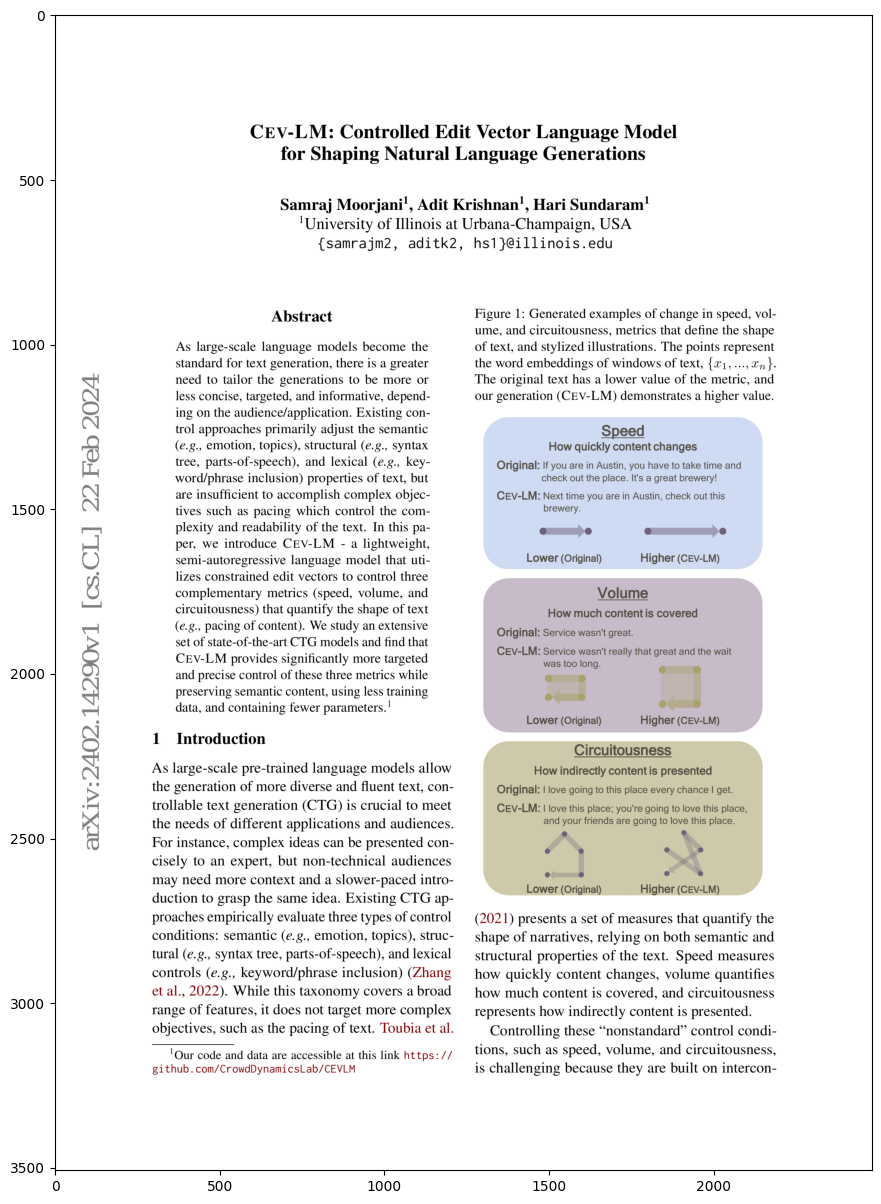

In [12]:
image_path = "./data/sample_page.png"
img = cv2.imread(image_path)
plt.figure(figsize = (15,15))
plt.imshow(img)

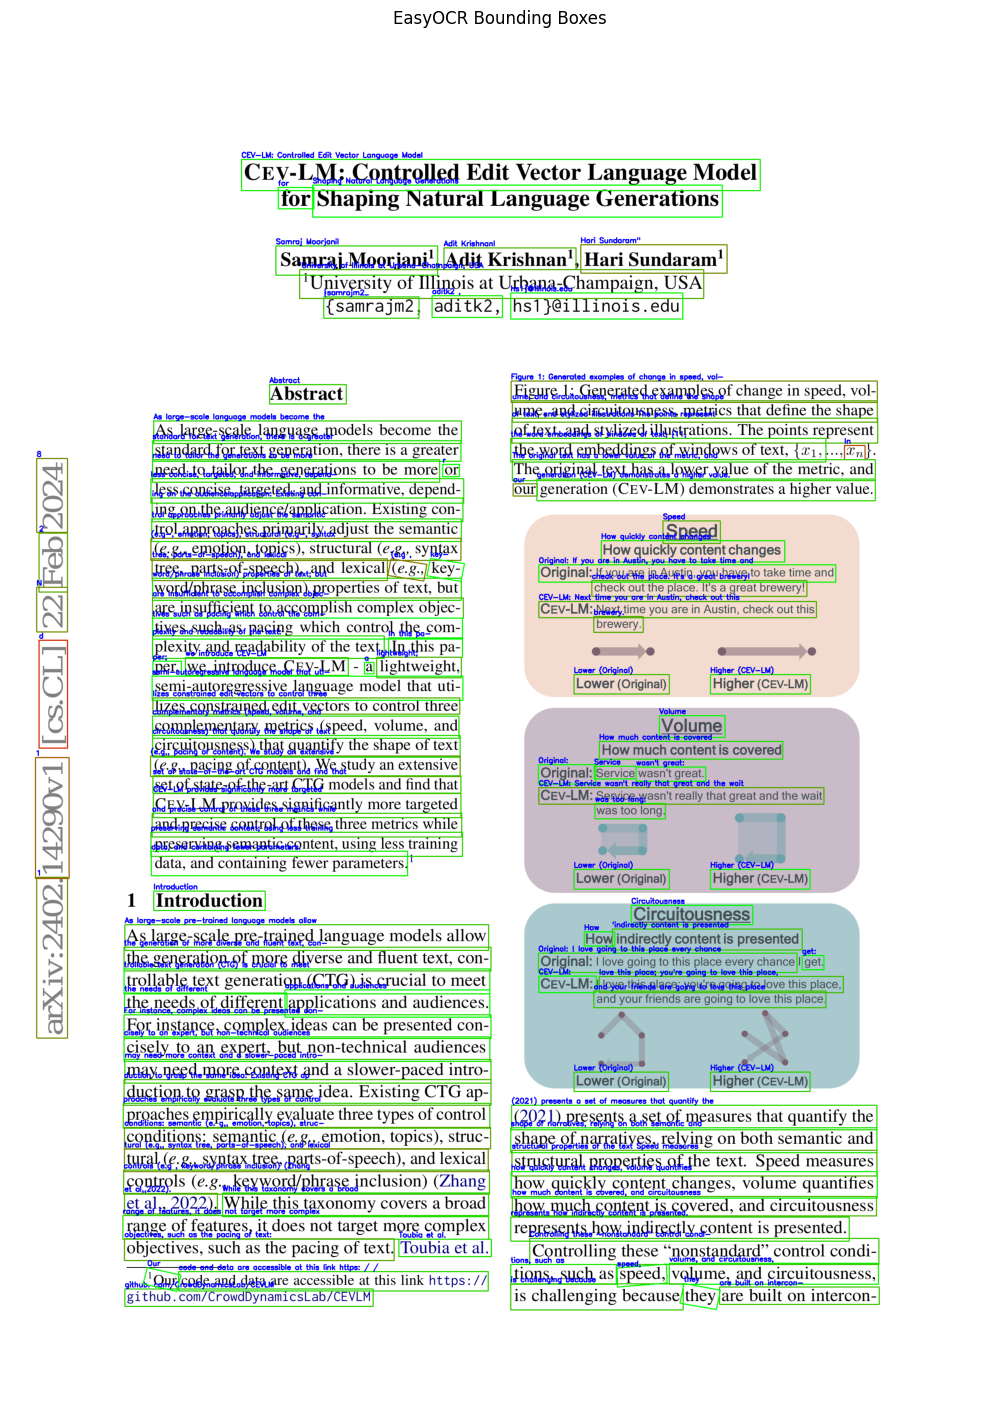

In [13]:
# Visualize the bounding boxes and text on the image
img = cv2.imread(image_path)
img_plot = img.copy()
show_text = True

# Function to color bboxes based on confidence score
def confidence_to_color(conf):
    """
    Converts a confidence score (0-1) to a BGR color (0-255).
    Red (low confidence) → Green (high confidence).
    """
    # Invert the confidence score so that low confidence is red and high confidence is green
    normalized_conf = 1.0 - conf

    # Red (255, 0, 0) → Green (0, 255, 0)
    red = int(255 * normalized_conf)      
    green = int(255 * conf)               
    blue = 0                              

    # Return color in BGR format for OpenCV
    return (blue, green, red)  

for bbox, text, conf in result:
    # Convert bbox to integer coordinates, sometimes they are floats
    # Transforms the list of points into a numpy array of shape (4, 2) for easier handling
    pts = np.array(bbox, dtype=int)

    # Confidence coloring
    color = confidence_to_color(conf)
    cv2.polylines(img_plot, [pts], True, color, 2)

    # Place text above the bounding box
    x, y = pts[0]
    if show_text:
        cv2.putText(img_plot, text, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(20, 18))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("EasyOCR Bounding Boxes")
plt.show()

In [14]:
from dataclasses import dataclass
from typing import List

@dataclass
class OCRRegion:
    text: str
    bbox: list           # [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
    confidence: float

    @property
    def bbox_xyxy(self):
        """A function to get the [x_min, y_min, x_max, y_max] — needed by LayoutReader for the layout identification"""
        xs = [p[0] for p in self.bbox]
        ys = [p[1] for p in self.bbox]
        return [min(xs), min(ys), max(xs), max(ys)]


ocr_regions: List[OCRRegion] = []
for bbox, text, conf in result:
    ocr_regions.append(OCRRegion(
        text=text,
        bbox=[[int(p[0]), int(p[1])] for p in bbox],
        confidence=float(conf),
    ))

print(f"Stored {len(ocr_regions)} OCR regions")

Stored 117 OCR regions


In [15]:
from transformers import LayoutLMv3ForTokenClassification
from src.scirex.layoutreader.v3.helpers import prepare_inputs, boxes2inputs, parse_logits

# Load LayoutReader model
print("Loading LayoutReader model...")
model_slug = "hantian/layoutreader"
layout_model = LayoutLMv3ForTokenClassification.from_pretrained(model_slug)
print("Model loaded successfully!")

Loading LayoutReader model...


Loading weights: 100%|██████████| 400/400 [00:00<00:00, 14229.92it/s]


Model loaded successfully!


In [16]:
def get_reading_order(ocr_regions):
    """
    Use LayoutReader to determine reading order of OCR regions.
    Returns list of reading order positions for each region index.
    """
    # 1. Calculate image dimensions from bounding boxes (with padding)
    max_x = max_y = 0
    for region in ocr_regions:
        x1, y1, x2, y2 = region.bbox_xyxy
        max_x = max(max_x, x2)
        max_y = max(max_y, y2)

    image_width = max_x * 1.1   # Add 10% padding
    image_height = max_y * 1.1

    # 2. Convert bboxes to LayoutReader format (normalized to 0-1000)
    boxes = []
    for region in ocr_regions:
        x1, y1, x2, y2 = region.bbox_xyxy
        # Normalize to 0-1000 range
        left = int((x1 / image_width) * 1000)
        top = int((y1 / image_height) * 1000)
        right = int((x2 / image_width) * 1000)
        bottom = int((y2 / image_height) * 1000)
        boxes.append([left, top, right, bottom])

    # 3. Prepare inputs
    inputs = boxes2inputs(boxes)
    inputs = prepare_inputs(inputs, layout_model)
    
    # 4. Run inference
    logits = layout_model(**inputs).logits.cpu().squeeze(0)
    
    # 5. Parse the model's outputs to get reading order
    reading_order = parse_logits(logits, len(boxes))

    return reading_order

# Get reading order
reading_order = get_reading_order(ocr_regions)

print(f"Reading order determined for {len(reading_order)} regions")
print(f"First 20 positions: {reading_order[:20]}")

Reading order determined for 117 regions
First 20 positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 21, 30, 35, 49, 63, 74, 10, 13, 15, 18]


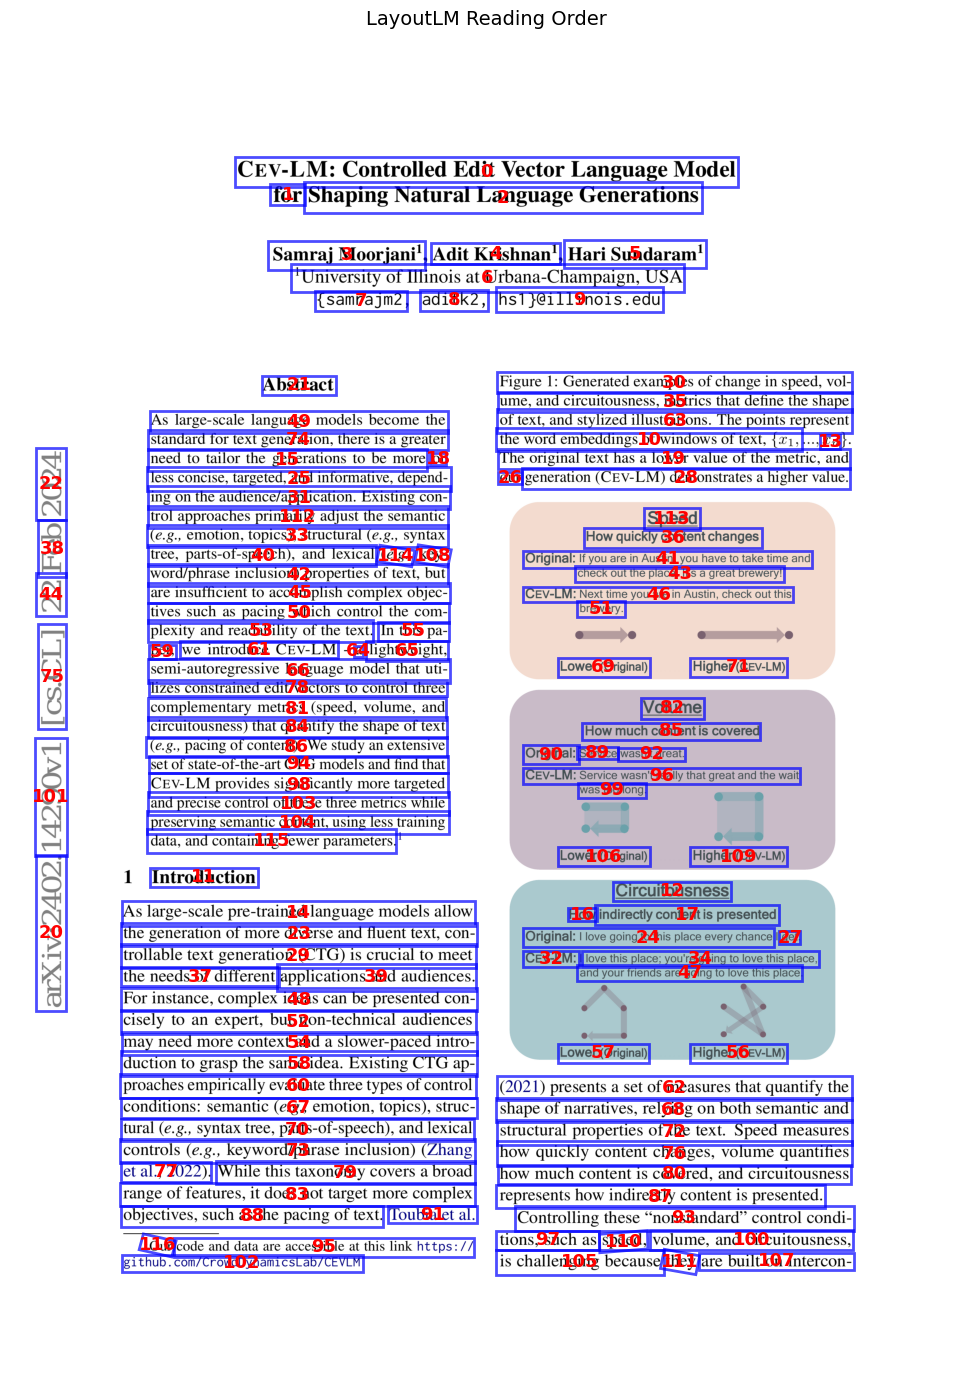

In [18]:
import matplotlib.patches as patches

def visualize_reading_order(ocr_regions, image_array, reading_order, title="Reading Order"):
    """
    Visualize OCR regions with their reading order numbers using matplotlib.
    """
    
    fig, ax = plt.subplots(1, figsize=(10, 14))
    ax.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
    
    # Create order mapping: index -> reading order position
    order_map = {i: order for i, order in enumerate(reading_order)}
    
    for i, region in enumerate(ocr_regions):
        bbox = region.bbox
        if bbox and len(bbox) >= 4:
            # Draw polygon
            ax.add_patch(patches.Polygon(bbox, linewidth=2, 
                                         edgecolor='blue',
                                         facecolor='none', alpha=0.7))
            # Add reading order number at center
            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            ax.text(sum(xs)/len(xs), sum(ys)/len(ys), 
                    str(order_map.get(i, i)),
                    fontsize=13, color='red', 
                    ha='center', va='center', fontweight='bold')
    
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_reading_order(ocr_regions, img, 
                        reading_order, "LayoutLM Reading Order")

In [19]:
# Create ordered text content
def get_ordered_text(ocr_regions, reading_order):
    """
    Return OCR regions sorted by reading order
    with their text and confidence.
    """
    # 1. Create (reading_position, index, region) tuples and sort
    indexed_regions = [(reading_order[i], 
                        i, 
                        ocr_regions[i]) for i in range(len(ocr_regions))]
    
    # 2. Sort by reading position
    indexed_regions.sort(key=lambda x: x[0])  
    
    # 3. Extract ordered text info
    ordered_text = []
    for position, original_idx, region in indexed_regions:
        ordered_text.append({
            "position": position,
            "text": region.text,
            "confidence": region.confidence,
            "bbox": region.bbox_xyxy
        })
    
    return ordered_text

ordered_text = get_ordered_text(ocr_regions, reading_order)

print("Text in reading order:")
print("=" * 70)
ordered_text[:5]

Text in reading order:


[{'position': 0,
  'text': 'CEV-LM: Controlled Edit Vector Language Model',
  'confidence': 0.9280551796389535,
  'bbox': [585, 322, 1897, 401]},
 {'position': 1,
  'text': 'for',
  'confidence': 0.9999888502748309,
  'bbox': [678, 393, 768, 447]},
 {'position': 2,
  'text': 'Shaping Natural Language Generations',
  'confidence': 0.9998140960357332,
  'bbox': [765, 387, 1801, 468]},
 {'position': 3,
  'text': 'Samraj Moorjanil',
  'confidence': 0.8336791444772045,
  'bbox': [672, 541, 1081, 615]},
 {'position': 4,
  'text': 'Adit Krishnanl',
  'confidence': 0.7084856617512485,
  'bbox': [1097, 546, 1431, 601]}]